# Logistic Regression from Scratch (Pandas + Pure Math)
Binary tweet sentiment classification — TF-IDF and gradient descent implemented with no numpy, no sklearn.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'nltk'])

0

## 1. Load Tweet Dataset (NLTK)

In [2]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples
import pandas as pd
import re

pos_tweets = twitter_samples.strings('positive_tweets.json')  # 5000 tweets
neg_tweets = twitter_samples.strings('negative_tweets.json')  # 5000 tweets

df = pd.DataFrame(
    [(t, 1) for t in pos_tweets] + [(t, 0) for t in neg_tweets],
    columns=["text", "label"]
)
print(f"Dataset: {len(df):,} tweets  |  Positive: {df.label.sum():,}  |  Negative: {(df.label==0).sum():,}")
df.head(3)

Dataset: 10,000 tweets  |  Positive: 5,000  |  Negative: 5,000


,text,label
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1
1,@Lamb2ja Hey James! How odd :/ Please call our...,1
2,@DespiteOfficial we had a listen last night :)...,1


## 2. Text Preprocessing

Clean tweets before building vocabulary: remove URLs, mentions, hashtag symbols,
punctuation, and lowercase everything.

In [3]:
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def clean(text: str) -> list:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)              # mentions
    text = re.sub(r'#', '', text)                 # hashtag symbol (keep word)
    text = re.sub(r'[^a-z\s]', '', text)          # punctuation & numbers
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

df['tokens'] = df['text'].apply(clean)
df[['text', 'tokens', 'label']].head(3)

,text,tokens,label
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,"[followfriday, top, engaged, members, communit...",1
1,@Lamb2ja Hey James! How odd :/ Please call our...,"[hey, james, odd, please, call, contact, centr...",1
2,@DespiteOfficial we had a listen last night :)...,"[listen, last, night, bleed, amazing, track, s...",1


## 3. Shuffle & Train / Test Split (80/20)

The raw data is ordered — 5,000 positives first, then 5,000 negatives.
A sequential split without shuffling would put **all negatives in the test set**,
making every prediction look biased toward positive. Shuffle with a fixed seed first.

In [4]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

split    = int(len(df) * 0.8)
train_df = df.iloc[:split].reset_index(drop=True)
test_df  = df.iloc[split:].reset_index(drop=True)

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")
print(f"Train — Pos: {train_df.label.sum():,}  Neg: {(train_df.label==0).sum():,}")
print(f"Test  — Pos: {test_df.label.sum():,}  Neg: {(test_df.label==0).sum():,}")

Train: 8,000  |  Test: 2,000
Train — Pos: 4,020  Neg: 3,980
Test  — Pos: 980  Neg: 1,020


## 4. Build Vocabulary (Top-N by Frequency)

Limit vocabulary to the top 3000 most frequent tokens in the **training set** only
to avoid data leakage and keep the feature matrix manageable.

In [5]:
from collections import Counter

VOCAB_SIZE = 3000

all_tokens = [tok for tokens in train_df['tokens'] for tok in tokens]
freq = Counter(all_tokens)
vocab = [word for word, _ in freq.most_common(VOCAB_SIZE)]
word2idx = {word: i for i, word in enumerate(vocab)}

print(f"Vocabulary size: {len(vocab):,}")
print(f"Top 10 tokens: {vocab[:10]}")

Vocabulary size: 3,000
Top 10 tokens: ['im', 'thanks', 'follow', 'like', 'love', 'please', 'get', 'good', 'dont', 'day']


## 5. TF-IDF Vectoriser from Scratch (Pure Python + Pandas)

**Term Frequency (TF):** how often a word appears in a document, normalised by doc length.
$$TF(t, d) = \frac{\text{count}(t, d)}{|d|}$$

**Inverse Document Frequency (IDF):** down-weights words that appear in many documents.
$$IDF(t) = \log\left(\frac{1 + N}{1 + df(t)}\right) + 1 \quad \text{(smoothed)}$$

**TF-IDF:** multiply and L2-normalise each row.
$$\text{tfidf}(t, d) = TF(t, d) \times IDF(t)$$

In [6]:
import math

def compute_idf(token_lists, vocab, word2idx):
    """IDF fitted on the given token lists."""
    N  = len(token_lists)
    df = {word: 0 for word in vocab}
    for tokens in token_lists:
        for word in set(tokens):
            if word in word2idx:
                df[word] += 1
    idf = {word: math.log((1 + N) / (1 + df[word])) + 1.0 for word in vocab}
    return idf


def tfidf_transform(token_lists, vocab, word2idx, idf):
    """Transform a list of token lists into a TF-IDF DataFrame."""
    rows = []
    for tokens in token_lists:
        cnt   = Counter(tokens)
        total = len(tokens) if len(tokens) > 0 else 1
        row   = [0.0] * len(vocab)
        for word, count in cnt.items():
            if word in word2idx:
                tf        = count / total
                row[word2idx[word]] = tf * idf[word]

        # L2 normalisation
        norm = math.sqrt(sum(v ** 2 for v in row)) or 1.0
        row  = [v / norm for v in row]
        rows.append(row)

    return pd.DataFrame(rows, columns=vocab)


# Fit IDF on train, transform both sets
idf_scores = compute_idf(train_df['tokens'].tolist(), vocab, word2idx)

print("Building TF-IDF matrix (this may take ~30s for 8000 docs × 3000 features)...")
X_train = tfidf_transform(train_df['tokens'].tolist(), vocab, word2idx, idf_scores)
X_test  = tfidf_transform(test_df['tokens'].tolist(),  vocab, word2idx, idf_scores)

y_train = train_df['label']
y_test  = test_df['label']

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Building TF-IDF matrix (this may take ~30s for 8000 docs × 3000 features)...
X_train: (8000, 3000)  |  X_test: (2000, 3000)


## 6. Add Bias Column

In [7]:
X_train.insert(0, 'bias', 1.0)
X_test.insert(0, 'bias', 1.0)

---
# Logistic Regression via Gradient Descent

No closed-form exists for logistic regression — we minimise Binary Cross-Entropy
iteratively using gradient descent.

**Sigmoid activation:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Prediction:**
$$\hat{p} = \sigma(X\beta)$$

**Binary Cross-Entropy loss:**
$$J(\beta) = -\frac{1}{n} \sum \left[ y \log(\hat{p}) + (1 - y) \log(1 - \hat{p}) \right]$$

**Gradient (same form as linear regression — elegant result of the sigmoid):**
$$\nabla_{\beta} J = \frac{1}{n} X^T (\hat{p} - y)$$

**Update:**
$$\beta \leftarrow \beta - \alpha \cdot \nabla_{\beta} J$$

## 7. Sigmoid (Pure Python)

In [8]:
def sigmoid(z: pd.Series) -> pd.Series:
    return z.apply(lambda v: 1.0 / (1.0 + math.exp(-max(-500, min(500, v)))))

## 8. Training Loop

In [9]:
def logistic_gradient_descent(X: pd.DataFrame, y: pd.Series,
                               lr=0.1, epochs=500, log_every=50):
    n      = len(X)
    beta   = pd.Series(0.0, index=X.columns)
    losses = []

    for epoch in range(1, epochs + 1):
        z      = X.dot(beta)                    # linear combination (n,)
        p_hat  = sigmoid(z)                     # predicted probabilities (n,)
        error  = p_hat - y.values               # (n,)
        error  = pd.Series(error, index=X.index)

        # BCE loss (clipped log to avoid log(0))
        loss = -(
            y.values * p_hat.apply(lambda v: math.log(max(v, 1e-15))) +
            (1 - y.values) * p_hat.apply(lambda v: math.log(max(1 - v, 1e-15)))
        ).mean()

        gradient = X.T.dot(error) / n           # (p,)
        beta     = beta - lr * gradient
        losses.append(loss)

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:>4} | Loss: {loss:.6f}")

    return beta, losses


beta, loss_history = logistic_gradient_descent(
    X_train, y_train, lr=0.5, epochs=300, log_every=50
)

Epoch    1 | Loss: 0.693147
Epoch   50 | Loss: 0.683923
Epoch  100 | Loss: 0.675227
Epoch  150 | Loss: 0.667171
Epoch  200 | Loss: 0.659689
Epoch  250 | Loss: 0.652724
Epoch  300 | Loss: 0.646223


## 9. Loss Curve

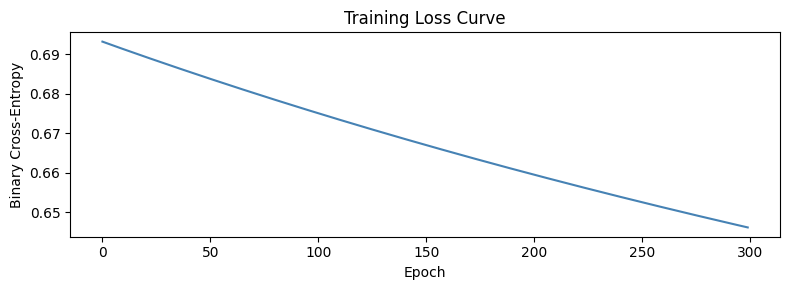

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy')
plt.title('Training Loss Curve')
plt.tight_layout()
plt.show()

## 10. Predictions & Evaluation

In [11]:
def predict(X, beta, threshold=0.5):
    probs = sigmoid(X.dot(beta))
    return probs.apply(lambda p: 1 if p >= threshold else 0)

def accuracy(y_true, y_pred):
    return (y_true.values == y_pred.values).sum() / len(y_true)

def confusion_matrix_manual(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    return pd.DataFrame([[tp, fn], [fp, tn]],
                        index=['Actual Pos', 'Actual Neg'],
                        columns=['Pred Pos', 'Pred Neg'])

y_pred_train = predict(X_train, beta)
y_pred_test  = predict(X_test,  beta)

print(f"Train Accuracy: {accuracy(y_train, y_pred_train):.4f}")
print(f"Test  Accuracy: {accuracy(y_test,  y_pred_test):.4f}")
print("\nConfusion Matrix (Test):")
confusion_matrix_manual(y_test.reset_index(drop=True), y_pred_test.reset_index(drop=True))

Train Accuracy: 0.7694
Test  Accuracy: 0.7315

Confusion Matrix (Test):


,Pred Pos,Pred Neg
Actual Pos,626,354
Actual Neg,183,837


## 11. Top Predictive Words

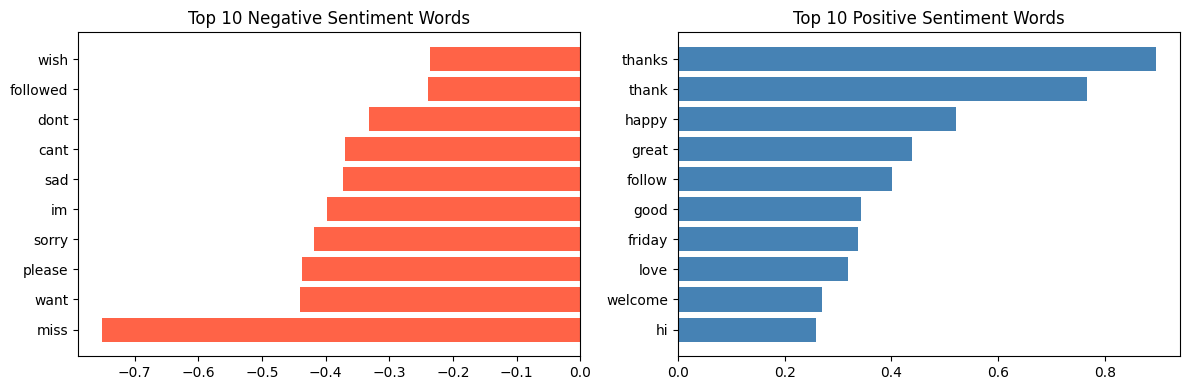

In [12]:
coef_series = beta.drop('bias').sort_values()
top_neg = coef_series.head(10)
top_pos = coef_series.tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh(top_neg.index, top_neg.values, color='tomato')
ax1.set_title('Top 10 Negative Sentiment Words')
ax2.barh(top_pos.index, top_pos.values, color='steelblue')
ax2.set_title('Top 10 Positive Sentiment Words')
plt.tight_layout()
plt.show()

## 12. Predict on a Custom Tweet

In [13]:
def predict_tweet(tweet: str, beta, vocab, word2idx, idf_scores, threshold=0.5):
    tokens   = clean(tweet)
    vec_df   = tfidf_transform([tokens], vocab, word2idx, idf_scores)
    vec_df.insert(0, 'bias', 1.0)
    prob     = sigmoid(vec_df.dot(beta)).iloc[0]
    label    = 'Positive 😊' if prob >= threshold else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {label}")

predict_tweet("I love this so much, absolutely amazing!", beta, vocab, word2idx, idf_scores)
print()
predict_tweet("I just can't talk, the day was pathetic", beta, vocab, word2idx, idf_scores)

Tweet:       I love this so much, absolutely amazing!
Probability: 0.5254
Sentiment:   Positive 😊

Tweet:       I just can't talk, the day was pathetic
Probability: 0.4774
Sentiment:   Negative 😞


## Save Model to `../Models/`

In [14]:
import json, os

model_data = {
    'vocab':      vocab,
    'idf':        idf_scores,                        # dict  word → idf value
    'beta':       beta.to_dict(),                    # dict  feature → coefficient
    'split':      {'seed': 42, 'test_size': 0.2}
}

save_path = '../Models/logreg_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/logreg_scratch.json  (207.0 KB)
